# Analisi Diffusione COVID-19 nel Mondo
**Report di Data Analysis sui dati di Our World in Data**

Questo notebook contiene un'analisi dettagliata sulla diffusione della pandemia di COVID-19, esplorando casi e vaccinazioni a livello globale e focalizzandosi su specifiche nazioni europee.

## Importazione dei dati 
Prima di rispondere alle richieste, importiamo le librerie necessarie e carichiamo il dataset direttamente dal repository GitHub di Our World in Data. Effettueremo una prima ispezione per comprenderne le dimensioni, i metadati e la natura delle variabili.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# URL del dataset direttamente dal repository OWID
url = 'https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv'

# Caricamento del dataset
df = pd.read_csv(url)
print("Dati caricati con successo!")

Dati caricati con successo!


##  Exploratory Data Analysis (EDA


In [4]:
print("Descrittori statistici di base")
df.describe()

Descrittori statistici di base


,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,4.118040e+05,4.101590e+05,4.089290e+05,4.118040e+05,410608.000000,409378.000000,411804.000000,410159.000000,408929.000000,411804.000000,...,243817.000000,161741.000000,290689.000000,390299.000000,319127.000000,4.294350e+05,1.341100e+04,13411.000000,13411.000000,13411.000000
mean,7.365292e+06,8.017360e+03,8.041026e+03,8.125957e+04,71.852139,72.060828,112096.199420,122.357073,122.713852,835.514337,...,33.097758,50.649390,3.106895,73.702098,0.722178,1.520336e+08,5.604765e+04,9.766431,10.925353,1772.666404
std,4.477582e+07,2.296649e+05,8.661611e+04,4.411901e+05,1368.322990,513.636565,162240.412405,1508.778585,559.701663,1134.932641,...,13.853952,31.905236,2.549168,7.387914,0.149237,6.975408e+08,1.568691e+05,12.040658,24.560706,1991.892770
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.190000,0.100000,53.280000,0.390000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2936.450000
25%,6.280750e+03,0.000000e+00,0.000000e+00,4.300000e+01,0.000000,0.000000,1916.100000,0.000000,0.000000,24.570000,...,22.600000,20.860000,1.300000,69.500000,0.600000,5.237980e+05,1.765000e+02,2.060000,-1.500000,116.875000
50%,6.365300e+04,0.000000e+00,1.200000e+01,7.990000e+02,0.000000,0.000000,29145.480000,0.000000,2.790000,295.090000,...,33.100000,49.540000,2.500000,75.050000,0.740000,6.336393e+06,6.815200e+03,8.130000,5.660000,1270.800000
75%,7.582720e+05,0.000000e+00,3.132900e+02,9.574000e+03,0.000000,3.140000,156770.190000,0.000000,56.250000,1283.820000,...,41.500000,82.500000,4.210000,79.460000,0.830000,3.296952e+07,3.912804e+04,15.160000,15.575000,2883.025000
max,7.758668e+08,4.423623e+07,6.319461e+06,7.057132e+06,103719.000000,14817.000000,763598.600000,241758.230000,34536.890000,6601.110000,...,78.100000,100.000000,13.800000,86.750000,0.960000,7.975105e+09,1.349776e+06,78.080000,378.220000,10293.520000


In [5]:
df.isna().sum()

iso_code                                        0
continent                                   26525
location                                        0
date                                            0
total_cases                                 17631
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality                           416024
excess_mortality_cumulative_per_million    416024
Length: 67, dtype: int64

### Esplorazione della relazione tra 'continent' e 'location'
Osservando le prime righe del dataset, notiamo la presenza di due colonne geografiche: `continent` e `location`. Vogliamo capire se `location` contiene solo nomi di nazioni o anche raggruppamenti più ampi. Per farlo, verifichiamo cosa succede nella colonna `location` quando la colonna `continent` è vuota (Null/NaN).
Filtriamo il dataset prendendo solo le righe dove 'continent' è nullo (NaN),e guardiamo quali sono i valori unici presenti nella colonna 'location'

In [6]:
aggregati = df[df['continent'].isna()]['location'].unique()

print("Valori di 'location' quando 'continent' non è specificato:")
print(aggregati)

Valori di 'location' quando 'continent' non è specificato:
['Africa' 'Asia' 'Europe' 'European Union (27)' 'High-income countries'
 'Low-income countries' 'Lower-middle-income countries' 'North America'
 'Oceania' 'South America' 'Upper-middle-income countries' 'World']


### Analisi della natura delle variabili 'new_cases' e 'total_cases'
Per comprendere la differenza tra casi giornalieri/settimanali e totali, verifichiamo il loro comportamento nel tempo. Possiamo dimostrare la loro natura analizzando le variazioni nel tempo. 
Verificheremo se i `total_cases` sono cumulativi (cioè non diminuiscono mai nel tempo) e se i `new_cases` fluttuano.
Filtriamo i dati per una nazione specifica per vedere l'andamento nel tempo (es. Italia)

In [7]:
df_italia = df[df['location'] == 'Italy'].sort_values('date').dropna(subset=['new_cases', 'total_cases'])

# 1. Controlliamo se i casi totali diminuiscono mai 
# Usiamo il metodo diff() che calcola la differenza con il giorno precedente.
diminuzioni_totali = (df_italia['total_cases'].diff() < 0).sum()

print(f"Volte in cui i 'total_cases' sono diminuiti rispetto al giorno prima: {diminuzioni_totali}")

# 2. Controlliamo quante volte i nuovi casi scendono a zero
giorni_zero_casi = (df_italia['new_cases'] == 0).sum()
print(f"Giorni con 0 'new_cases' registrati durante la pandemia: {giorni_zero_casi}")

statistiche_casi = df[['new_cases', 'total_cases']].describe()
print("\n--- Statistiche descrittive globali ---")
print(statistiche_casi)

Volte in cui i 'total_cases' sono diminuiti rispetto al giorno prima: 0
Giorni con 0 'new_cases' registrati durante la pandemia: 1440

--- Statistiche descrittive globali ---
          new_cases   total_cases
count  4.101590e+05  4.118040e+05
mean   8.017360e+03  7.365292e+06
std    2.296649e+05  4.477582e+07
min    0.000000e+00  0.000000e+00
25%    0.000000e+00  6.280750e+03
50%    0.000000e+00  6.365300e+04
75%    0.000000e+00  7.582720e+05
max    4.423623e+07  7.758668e+08


### PRECISAZIONE
Volevo precisare che prima di andare avanti mi sono accertato che i dati NaN che hp eliminato per trarre le conclusioni "EDA" siano una piccola percentuale e che non intacchino il flusso dei dati del dataset,ho deciso di non aggiungere questi passaggi per non 

### Conclusioni dell'esplorazione (EDA)

Grazie all'esplorazione appena effettuata, abbiamo dedotto due logiche fondamentali per il prosieguo dell'analisi:

1. **La relazione tra `continent` e `location`:**
   - La colonna `location` contiene sia **dati puntuali** (le singole nazioni, es. "Italy", "France") sia **dati aggregati** (es. "World", "Europe", "High income").
   - La colonna `continent` ci aiuta a distinguerli: per le singole nazioni, contiene il nome del continente. Tuttavia, per i dati aggregati, la colonna `continent` è `NaN` (nulla). Questo sarà il nostro "trucco" per escludere i raggruppamenti globali quando vorremo analizzare solo i singoli stati.
2. **Logica dei casi:** - `total_cases` rappresenta uno **stock cumulativo**: come dimostrato dall'assenza di diminuzioni nel tempo (le differenze col giorno precedente non sono mai negative), questa curva somma tutti i casi dall'inizio.
   - `new_cases` rappresenta un **flusso**: i valori oscillano costantemente e possono toccare lo zero, indicando i casi registrati unicamente in quel lasso di tempo.

## Punto 1: Dimensioni del dataset e metadati

> **Traccia:** Si richiede di verificare le dimensioni del dataset e i relativi metadati.

In questa prima fase,verificheremo il numero totale di righe (osservazioni) e colonne (variabili), per poi estrarre i metadati. I metadati ci forniranno informazioni cruciali sui tipi di dato (es. interi, float, stringhe, date) e ci aiuteranno a capire quanta memoria sta occupando il dataset.

In [8]:
righe = df.shape[0]
colonne = df.shape[1]

print("--- Dimensioni del Dataset ---")
print(f"Il dataset contiene {righe} righe e {colonne} colonne.\n")

print("--- Metadati del Dataset ---")
df.info()

--- Dimensioni del Dataset ---
Il dataset contiene 429435 righe e 67 colonne.

--- Metadati del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                          

## Punto 2: Analisi dei casi per Continente

> **Traccia:** Si chiede di trovare, per ogni continente: a) il numero di casi fin dall'inizio della pandemia; b) la percentuale rispetto al totale mondiale del numero di casi.


1. Cercheremo nella colonna `location` i nomi esatti dei continenti e il valore "World".
2. Poiché la colonna `total_cases` rappresenta uno stock cumulativo, il numero totale di casi dall'inizio della pandemia fino all'ultimo giorno di rilevazione corrisponde semplicemente al valore massimo (`max()`) registrato in quella colonna per ogni determinata area geografica.

In [9]:
# Diciamo a Python quali sono i continenti
nomi_continenti = ['Europe', 'Asia', 'North America', 'South America', 'Africa', 'Oceania']

df_continenti = df[df['location'].isin(nomi_continenti)]

In [10]:
# Calcoliamo il totale dei casi per continente
# Raggruppiamo per location e prendiamo il valore massimo (max) dei casi totali
casi_per_continente = df_continenti.groupby('location')['total_cases'].max()

In [11]:
# Calcoliamo i casi totali nel Mondo per poter fare la percentuale
# Filtriamo dove location è "World" e prendiamo il massimo
casi_mondo = df[df['location'] == 'World']['total_cases'].max()

In [12]:
# Creiamo una nuova tabella (DataFrame) bella e ordinata per ospitare i risultati
tabella_risultati = pd.DataFrame({'Casi_Totali': casi_per_continente})

In [13]:
# Aggiungiamo la colonna con la percentuale rispetto al mondo
# La formula è: (Casi del continente / Casi del mondo) * 100
tabella_risultati['Percentuale_su_Mondo (%)'] = (tabella_risultati['Casi_Totali'] / casi_mondo) * 100

In [14]:
# Ordiniamo la tabella dal continente con più casi a quello con meno casi
tabella_risultati = tabella_risultati.sort_values(by='Casi_Totali', ascending=False)

In [15]:
print(f"Casi totali registrati nel Mondo: {casi_mondo:,.0f}\n")

display(tabella_risultati[['Casi_Totali', 'Percentuale_su_Mondo (%)']])

Casi totali registrati nel Mondo: 775,866,783



,Casi_Totali,Percentuale_su_Mondo (%)
location,,
Asia,301499099.0,38.859648
Europe,252916868.0,32.597976
North America,124492666.0,16.045624
South America,68809418.0,8.868716
Oceania,15003352.0,1.933754
Africa,13145380.0,1.694283


## PUNTO 3. Analisi dell'Italia nel 2022 (Casi Totali e Nuovi Casi)

> **Traccia:** Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati: A) l'evoluzione dei casi totali dall'inizio alla fine dell'anno; B) il numero di nuovi casi rispetto alla data.



In [16]:
# Convertiamo la colonna 'date' in formato datetime per permettere a Pandas di capire il tempo
df['date'] = pd.to_datetime(df['date'])

# 1. Filtriamo il dataset mantenendo solo l'Italia
df_italia = df[df['location'] == 'Italy']

# 2. Estraiamo l'anno 2022 grazie alla proprietà '.dt.year'
df_italia_2022 = df_italia[df_italia['date'].dt.year == 2022]


### 3.1 Pulizia dei giorni senza misurazioni
Nel 2022 le comunicazioni dei contagi sono passate a cadenza settimanale. Per evitare che i grafici mostrino dei "buchi"nei giorni non lavorativi, eliminiamo le righe in cui i `new_cases` sono nulli o pari a zero.

In [17]:
# 1. Rimuoviamo i valori nulli (NaN) dalla colonna dei nuovi casi
df_italia_2022_pulito = df_italia_2022.dropna(subset=['new_cases'])

# 2. Manteniamo solo i giorni in cui c'è stata una comunicazione effettiva (casi > 0)
df_italia_2022_pulito = df_italia_2022_pulito[df_italia_2022_pulito['new_cases'] > 0]

### 3.2 Grafico A: Evoluzione dei casi totali (Stock Cumulativo)
Visualizziamo la curva di crescita dei casi totali. L'utilizzo di un grafico a linee con dei "marker" (i punti) ci permette di vedere chiaramente i singoli momenti in cui il bollettino è stato rilasciato.

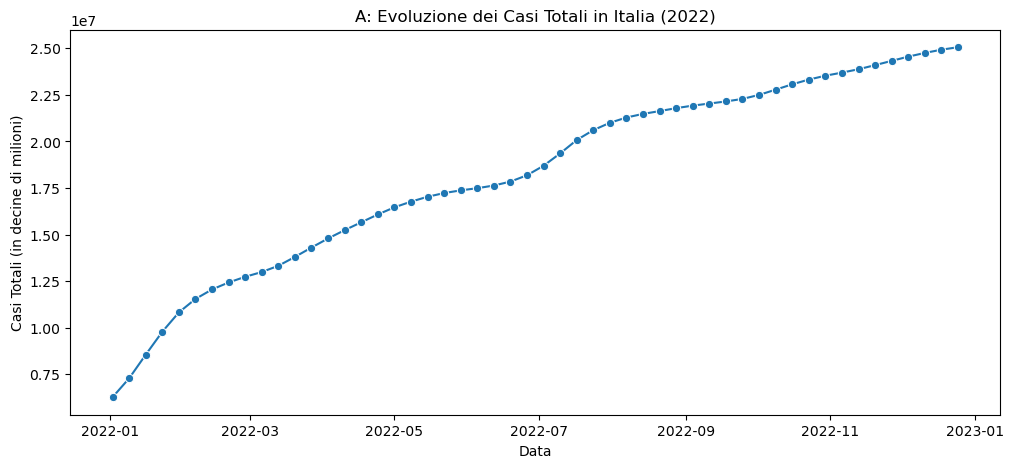

In [18]:
# Impostiamo la dimensione della figura
plt.figure(figsize=(12, 5))

# Disegniamo la linea
sns.lineplot(data=df_italia_2022_pulito, x='date', y='total_cases',  marker='o')

# Aggiungiamo titoli e dettagli grafici
plt.title("A: Evoluzione dei Casi Totali in Italia (2022)")
plt.ylabel("Casi Totali (in decine di milioni)")
plt.xlabel("Data")


plt.show()

### 3.3 Grafico B: Andamento dei nuovi casi (Flusso Settimanale)
Visualizziamo ora le "ondate" pandemiche del 2022 analizzando il flusso dei nuovi casi registrati ad ogni rilascio del bollettino.

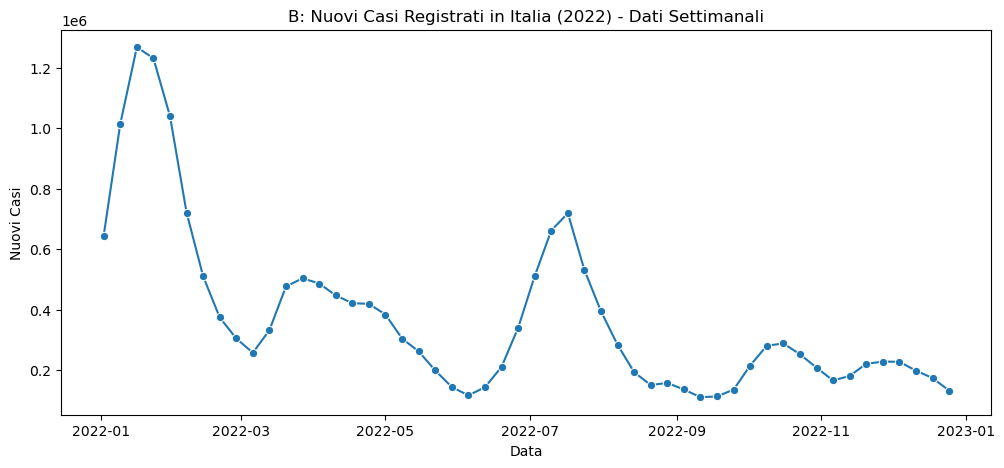

In [19]:
plt.figure(figsize=(12, 5))

sns.lineplot(data=df_italia_2022_pulito, x='date',  y='new_cases', marker='o')

plt.title("B: Nuovi Casi Registrati in Italia (2022) - Dati Settimanali")
plt.ylabel("Nuovi Casi")
plt.xlabel("Data")

plt.show()

## 4. Analisi Terapie Intensive: Italia, Germania e Francia

> **Traccia:** Riguardo Italia, Germania e Francia: A) mostrare in un boxplot la differenza riguardo il numero di pazienti in terapia intensiva (`icu_patients`) da maggio 2022 ad aprile 2023 inclusi. B) Scrivere un breve commento conclusivo.

### 4.1 Filtraggio Geografico e Temporale
Per procedere, dobbiamo prima estrarre un sottoinsieme di dati che rispetti tre condizioni contemporaneamente:
1. Le nazioni devono essere esclusivamente Italia, Germania e Francia.
2. La data deve essere maggiore o uguale al 1° Maggio 2022.
3. La data deve essere minore o uguale al 30 Aprile 2023.

In [20]:
# 1. Definiamo la lista delle tre nazioni target
nazioni_target = ['Italy', 'Germany', 'France']

# 2. Definiamo le date di inizio e fine del periodo di interesse
# Usiamo il formato YYYY-MM-DD che è lo standard per i calcoli temporali
data_inizio = '2022-05-01'
data_fine = '2023-04-30'

# 3. Creiamo il filtro combinato applicando tutte le condizioni

df_terapie = df[ (df['location'].isin(nazioni_target)) & (df['date'] >= data_inizio) & (df['date'] <= data_fine)]

# 4. Eliminiamo i valori nulli dalla colonna di nostro interesse (icu_patients) per non falsare i calcoli statistici del boxplot
df_terapie = df_terapie.dropna(subset=['icu_patients'])

### 4.2 Visualizzazione tramite Boxplot (A)
Utilizzeremo la libreria `seaborn`, che è ottimizzata per la creazione di grafici statistici. Il boxplot ci permetterà di visualizzare contemporaneamente la mediana, la dispersione (range interquartile) e gli eventuali valori anomali (outliers) dei pazienti in terapia intensiva per ciascuna delle tre nazioni nel periodo selezionato.

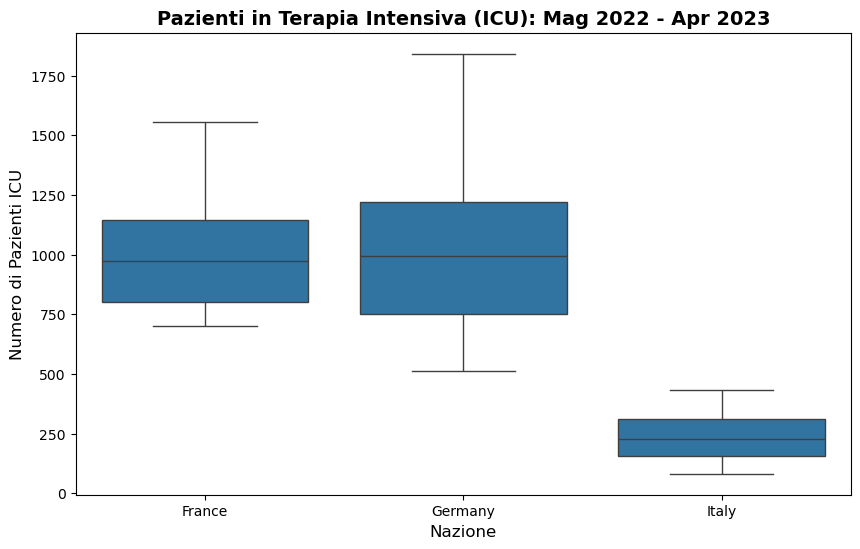

In [21]:
# Impostiamo le dimensioni del grafico
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_terapie, x='location', y='icu_patients')
# Aggiungiamo titoli e formattazioni per renderlo professionale
plt.title("Pazienti in Terapia Intensiva (ICU): Mag 2022 - Apr 2023", fontsize=14, fontweight='bold')
plt.xlabel("Nazione", fontsize=12)
plt.ylabel("Numero di Pazienti ICU", fontsize=12)

# Mostriamo il grafico
plt.show()

### 4.3 Conclusioni sull'analisi delle Terapie Intensive (B)

Osservando il boxplot, possiamo trarre due conclusioni principali sul periodo Maggio 2022 - Aprile 2023:
1. **Volumi complessivi:** L'Italia ha mantenuto un numero di pazienti in terapia intensiva (mediana intorno a 250) drasticamente inferiore rispetto a Francia e Germania (entrambe con mediane vicine a 1000).
2. **Variabilità:** La Germania presenta la dispersione maggiore, indicando forti oscillazioni e picchi di ricoveri gravi molto più marcati rispetto alla stabilità dell'Italia.

## 5. Analisi Ospedalizzazioni 2021: Italia, Germania, Francia e Spagna

> **Traccia:** Riguardo Italia, Germania, Francia e Spagna in tutto il 2021: A) mostrare la somma dei pazienti ospedalizzati (`hosp_patients`) per ognuna; B) analizzare la presenza di dati nulli e commentare la possibilità di gestirli tramite sostituzione.

### 5.1 Preparazione del Dataset (Target 2021)
Iniziamo isolando le quattro nazioni richieste e limitando l'analisi all'anno solare 2021.

In [22]:
# 1. Lista delle nazioni richieste
nazioni_5 = ['Italy', 'Germany', 'France', 'Spain']

# 2. Filtriamo per nazione e per l'anno 2021
df_2021 = df[(df['location'].isin(nazioni_5)) & (df['date'].dt.year == 2021)]

# Creiamo una copia per lavorare in sicurezza
df_ospedali = df_2021[['location', 'date', 'hosp_patients']].copy()

### 5.2 Analisi dei Dati Mancanti (Punto B)
Prima di calcolare la somma, dobbiamo capire quanto è "integra" la colonna `hosp_patients`. Se mancano molti dati, la somma finale sarà pesantemente sottostimata. Verifichiamo quanti valori nulli sono presenti per ogni nazione.

In [23]:
# 1. Calcoliamo quante righe (giorni) in totale ci sono per ogni nazione.
# Il comando .size() conta tutte le righe, inclusi i buchi (NaN)
giorni_totali = df_ospedali.groupby('location')['hosp_patients'].size()

# 2. Calcoliamo quanti giorni hanno un dato valido (un numero scritto dentro).
# Il comando .count() è speciale: conta solo i valori reali e IGNORA i buchi (NaN)
giorni_validi = df_ospedali.groupby('location')['hosp_patients'].count()

# 3. Facciamo una semplice sottrazione matematica per trovare i nulli
nulli_per_nazione = giorni_totali - giorni_validi

print("Valori nulli (giorni mancanti) per 'hosp_patients' nel 2021:")
print(nulli_per_nazione)

Valori nulli (giorni mancanti) per 'hosp_patients' nel 2021:
location
France       0
Germany    365
Italy        0
Spain        0
Name: hosp_patients, dtype: int64


### Commento sulla gestione dei dati nulli e Scelta Operativa
Dall'analisi precedente è emerso un dato critico: la **Germania presenta 365 valori nulli**, il che significa che il dato `hosp_patients` è totalmente assente per l'intero anno 2021. Italia, Francia e Spagna, al contrario, presentano dati completi (0 nulli).

Non è matematicamente possibile applicare una sostituzione su un intero anno mancante. Mantenere la Germania nel calcolo farebbe risultare una somma pari a 0, creando un grafico fuorviante. 
Pertanto, per tutelare l'integrità dell'analisi, **la Germania verrà esclusa dal confronto finale** sulle ospedalizzazioni.


In [24]:
# 1. Ridefiniamo la lista escludendo la Germania
nazioni_valide = ['Italy', 'France', 'Spain']

# 2. Filtriamo il nostro dataset del 2021 mantenendo solo queste tre nazioni
df_ospedali_validi = df_ospedali[df_ospedali['location'].isin(nazioni_valide)]

# 3. Calcoliamo la somma corretta
somma_ospedalizzati = df_ospedali_validi.groupby('location')['hosp_patients'].sum()



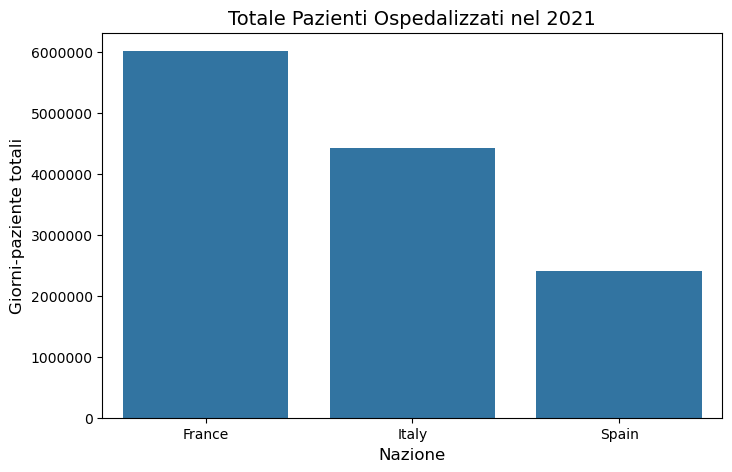

Dati esatti:
location
France    6008717.0
Italy     4419950.0
Spain     2411706.0
Name: hosp_patients, dtype: float64


In [25]:

plt.figure(figsize=(8, 5))

# 2. Creiamo il grafico a barre con Seaborn passando i dati originali
sns.barplot(x=somma_ospedalizzati.index, y=somma_ospedalizzati.values)

plt.title("Totale Pazienti Ospedalizzati nel 2021", fontsize=14)
plt.xlabel("Nazione", fontsize=12)
plt.ylabel("Giorni-paziente totali", fontsize=12)

# Impone a Python di scrivere 6000000 per intero sull'asse Y
plt.ticklabel_format(style='plain', axis='y')

plt.show()

print("Dati esatti:")
print(somma_ospedalizzati)